## Check out the related blog post!
https://www.instagram.com/p/DYae0jcCBWu/?utm_source=ig_web_copy_link&igsh=MzRlODBiNWFlZA==

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Open the image and get the most frequent color to assume as background
img = Image.open('/content/bg.png')
img_small = img.resize((50, 50))
colors = img_small.getcolors(2500)
bg_color_rgb = max(colors, key=lambda x: x[0])[1]
bg_hex = '#%02x%02x%02x' % bg_color_rgb[:3]
print(f'Extracted background color: {bg_hex}')

## Optimizers
Following the survey on optimization algorithms: https://arxiv.org/pdf/1609.04747

Implementing all optimizers on the basis of the following problem: **a univariate regression with parameters $\beta_0, \beta_1$**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_optimization_progress(
        X_data, y_data,
        loss_fn, grad_fn,
        path=None,
        w0_range=(-20, 40), w1_range=(10, 100),
        title = 'Optimization Progress',
        rotate_loss_by_deg = 30,
        intensity = 100
    ):
    """
    Plots the 3D loss surface and 2D contour map with high resolution for any arbitrary loss/grad functions.
    """
    bg_color = '#13171b'
    text_color = 'white'

    w0_grid = np.linspace(w0_range[0], w0_range[1], intensity)
    w1_grid = np.linspace(w1_range[0], w1_range[1], intensity)
    W0, W1 = np.meshgrid(w0_grid, w1_grid)

    Z = np.zeros_like(W0)
    grad_intensity = np.zeros_like(W0)

    for i in range(W0.shape[0]):
        for j in range(W0.shape[1]):
            w = np.array([W0[i, j], W1[i, j]])
            y_p = np.hstack([np.ones_like(X_data), X_data]) @ w

            # Use the passed-in generalized functions
            z_val = loss_fn(y_data, y_p)
            # If loss_fn returns an array (per-sample), take the mean
            Z[i, j] = np.mean(z_val)

            grads = grad_fn(X_data, y_data, y_p)
            grad_intensity[i, j] = np.linalg.norm(grads)

    fig = plt.figure(figsize=(16, 7), facecolor=bg_color)

    # 3D Surface
    ax1 = fig.add_subplot(1, 2, 1, projection='3d', facecolor=bg_color)
    surf = ax1.plot_surface(W0, W1, Z, cmap='viridis', alpha=0.8, antialiased=True)
    ax1.set_title('Loss Landscape', color=text_color)
    ax1.tick_params(colors=text_color)
    ax1.view_init(elev=30, azim=-rotate_loss_by_deg)
    ax1.xaxis.pane.fill = ax1.yaxis.pane.fill = ax1.zaxis.pane.fill = False

    # 2D Contour & Path
    ax2 = fig.add_subplot(1, 2, 2, facecolor=bg_color)
    im = ax2.imshow(grad_intensity, extent=[w0_range[0], w0_range[1], w1_range[0], w1_range[1]],
                    origin='lower', cmap='magma', alpha=0.8, aspect='auto')

    contours = ax2.contour(W0, W1, Z, levels=20, colors='white', linewidths=0.6, alpha=0.7)
    ax2.clabel(contours, inline=True, fontsize=8, fmt='%.1f')

    if path is not None:
        path = np.array(path)
        ax2.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='Optimization Path', color='#ff3333')
        ax2.scatter(path[0, 0], path[0, 1], color='#00d9ff', s=100, label='Start', zorder=5)
        ax2.scatter(path[-1, 0], path[-1, 1], color='#33ff33', s=100, label='End', zorder=5)
        leg = ax2.legend(loc='upper right', facecolor=bg_color, edgecolor=text_color, labelcolor=text_color)

    ax2.set_title('Gradient Intensity Map', color=text_color)
    ax2.tick_params(colors=text_color)
    cbar = fig.colorbar(im, ax=ax2)
    cbar.ax.yaxis.set_tick_params(color=text_color)
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color=text_color)

    fig.suptitle(title, color=text_color, fontsize=16)
    plt.tight_layout()
    plt.show()

## Vanilla/batch gradient descent: sum over all points in $X$.

Let's review something trivial first: $MSE(y,y_{pred})=\frac{1}{N}\sum{(y-y_{pred})^2}$.

It is trivial, because the hessian $H = \nabla^2 L(\theta) = \frac{1}{N} X^T X=const\implies$ curvature is predictable.

More formally, Hessian is Positive Definite ($\lambda_i\gt0$)$\implies$ the function is $\mu$-strongly convex. L-smoothness paired with $\mu$-strong convexity guarantees linear convergence rate $O(e^{-cT})$, where: $c = \mu/L$.

In [3]:
from sklearn import linear_model, datasets
n_samples = 1000
n_outliers = 50
X, y, coef = datasets.make_regression(
  n_samples=n_samples, n_features=1,
  n_informative=1, noise=10,
  bias=10.5, coef=True, random_state=0
)
initial_coeffs = np.array([0,coef-50])

/tmp/ipykernel_1398/3389250277.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r.-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='Optimization Path', color='#ff3333')


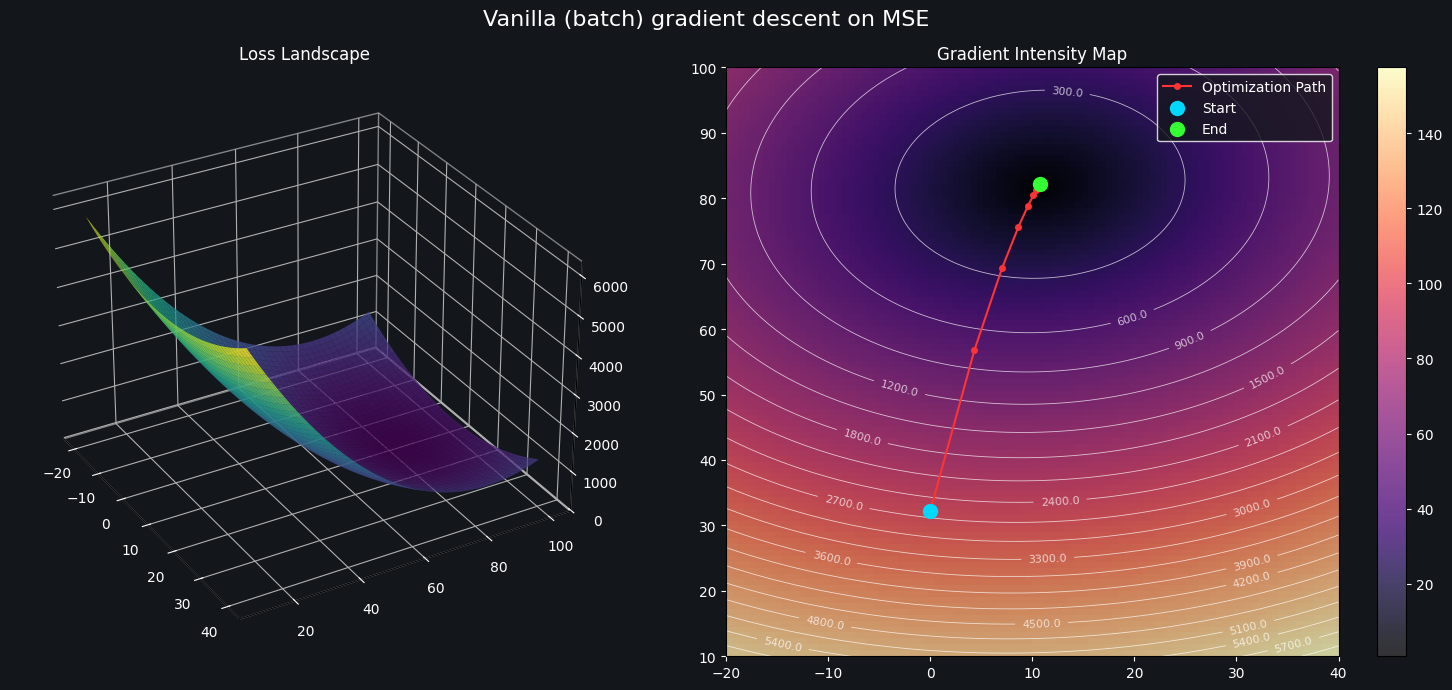

In [ ]:
def loss_fn(y, y_pred): return 1/n_samples * np.sum((y - y_pred) ** 2)
def grad_fn(X, y, y_pred):
    err = y_pred - y
    g0 = 2 * np.mean(err)
    g1 = 2 * np.mean(X.T * err)
    return np.array([g0, g1])

current_w = initial_coeffs.copy().astype(float)
path = [current_w.copy()]

eigv, eigvec = np.linalg.eig(X.T @ X)
L = 2/n_samples * np.max(eigv)
lr = round(1/L, 2) * 0.5 # 50% of the largest safest step

N_EPOCHS = 30

for _ in range(N_EPOCHS):
    y_pred = np.hstack([np.ones_like(X), X]) @ current_w
    grad = grad_fn(X, y, y_pred)
    current_w -= lr * grad
    path.append(current_w.copy())

plot_optimization_progress(
  X, y, loss_fn=loss_fn, grad_fn=grad_fn,
  path=path, rotate_loss_by_deg=30,
  title=f'Vanilla (batch) gradient descent on MSE'
)

What about something harder, e.g. a **Tukey loss function**, that is very insensitive to outliers:
$$L(r) =
\begin{cases}
\frac{c^2}{6} \left[ 1 - \left( 1 - \left(\frac{r}{c}\right)^2 \right)^3 \right] & \text{if } |r| \leq c \\
\frac{c^2}{6} & \text{if } |r| > c
\end{cases}\quad [1]$$
,where: $r = \hat{y} - y$

[1] https://www.r-bloggers.com/2021/04/what-is-the-tukey-loss-function/

Before diving into the problems with the Tukey loss however, let's unpack it:

By applying Binomial theorem we unpack the first equation:
$$
L(r) = \frac{c^2}{6} \left[ 1 - \left( 1 - 3\left(\frac{r}{c}\right)^2 + 3\left(\frac{r}{c}\right)^4 - \left(\frac{r}{c}\right)^6 \right) \right] \\
L(r) = \frac{r^2}{2} - \frac{r^4}{2c^2} + \frac{r^6}{6c^4}
$$
Now for the derivative:
$$
\frac{\partial L(r_i)}{\partial r_i} = r_i \left( 1 - 2\left(\frac{r_i}{c}\right)^2 + \left(\frac{r_i}{c}\right)^4 \right)
$$
, which is:
$$
\frac{\partial L(r_i)}{\partial r_i} = r_i \left( 1 - \left(\frac{r_i}{c}\right)^2 \right)^2
$$
since the derivative for the second equation is $0$ we can assemble two in a single clean equation for the gradient:
$$
\nabla_\beta L(r_i) = x_i \cdot r_i \left( 1 - \left(\frac{r_i}{c}\right)^2 \right)^2 \cdot \mathbb{I}(|r_i| \leq c)
$$
and there is no need to calculate a separate derivative for $|r|=c$, because for $\pm c$ the following condition is going to be satisfied:
$$
\lim_{r \to c^+} \frac{\partial L(r)}{\partial r} = 0 = \\
\lim_{r \to c^-} \frac{\partial L(r)}{\partial r} = c \left( 1 - \left(\frac{c}{c}\right)^2 \right)^2 = \\
c (1 - 1)^2 = c(0) = 0
$$


/tmp/ipykernel_13699/1589910960.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r.-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='Optimization Path', color='#ff3333')


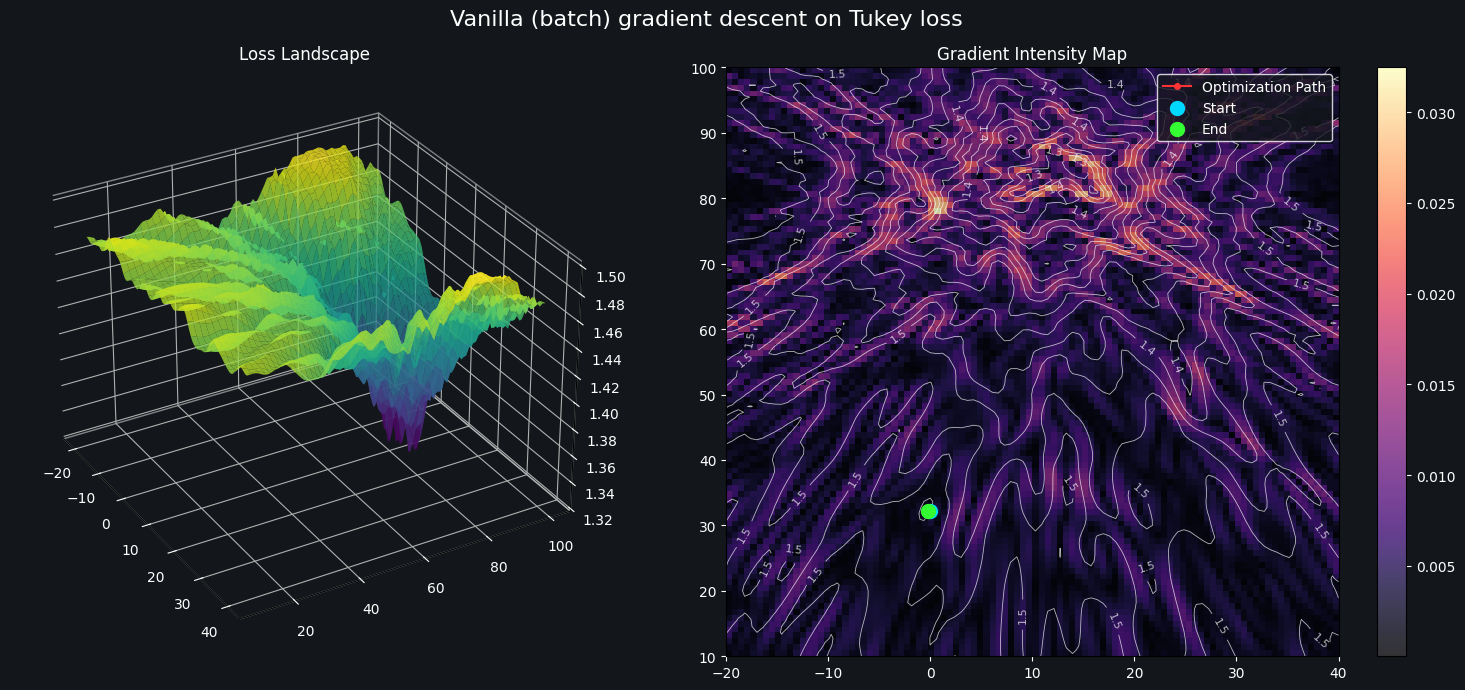

In [4]:
C = 3
C_sq = C ** 2

def indicator(err, C = C):
  return (np.abs(err) <= C)

def loss_fn(y, y_pred, C_sq = C_sq):
  err = y_pred - y
  z = 1 - (err ** 2 / C_sq)
  return np.where(indicator(err), (C_sq / 6) * (1 - z**3), C_sq / 6)

def grad_fn(X, y, y_pred, C_sq=C_sq):
    err = y_pred - y
    I = indicator(err).astype(int)
    z = 1 - (err ** 2 / C_sq)
    g0 = np.mean(err * z ** 2 * I)
    g1 = np.mean(X.T * err * z ** 2 * I)
    return np.array([g0, g1])

current_w = initial_coeffs.copy().astype(float)
path = [current_w.copy()]

lr = 1
N_EPOCHS = 100

for _ in range(N_EPOCHS):
    y_pred = np.hstack([np.ones_like(X), X]) @ current_w
    grad = grad_fn(X, y, y_pred)
    current_w -= lr * grad
    path.append(current_w.copy())

plot_optimization_progress(
  X, y,
  loss_fn=loss_fn, grad_fn=grad_fn,
  path=path, rotate_loss_by_deg=30,
  title=f'Vanilla (batch) gradient descent on Tukey loss'
)

So why are we not moving (start and end points of our optimization path are superimposed)? Because we agressively penalize gradient's signal from residuals above $C$ and take average of all $N$ points, including zero'ed out ones, we're getting a very poor understanding of the direction of change. Lipschitz constant would prove to be pointless if we find ourselves in a local minima, such as in the case of this loss function. So with our batch gradient descent we're left with these cheap options, that do not guarantee convergence to a global minima:
* Substantially increase learning rate at the start, decrease to an optimal value in the end
* Add noise to parameter updates:
$$
\beta_{t+1} = \beta_t - \eta \nabla_\beta L(\beta_t) + \mathcal{N}(0, \sigma^2_t)
$$
* Add L2-regularization:
$$
L_{new}(\beta) = L_{Tukey}(\beta) + \frac{\lambda}{2} \|\beta\|^2
$$

/tmp/ipykernel_5311/1589910960.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r.-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='Optimization Path', color='#ff3333')


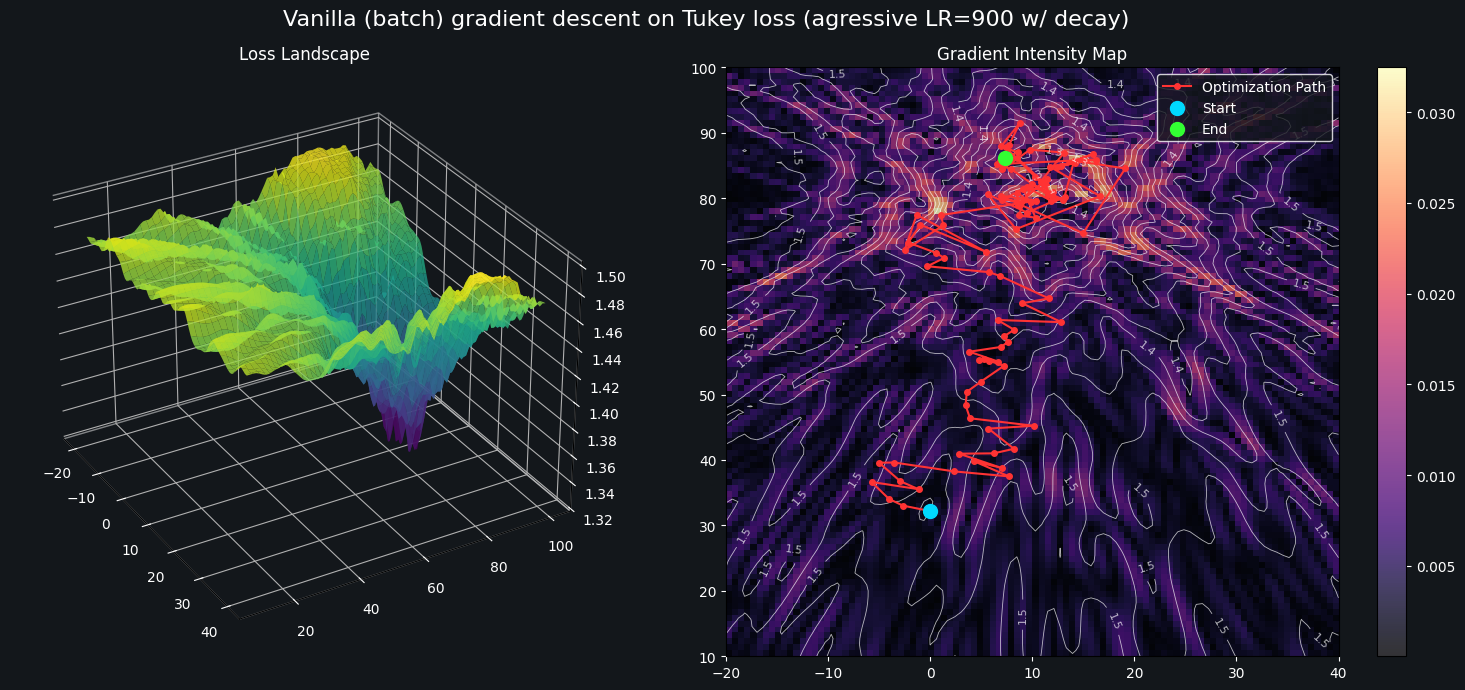

In [ ]:
current_w = initial_coeffs.copy().astype(float)
path_high_lr = [current_w.copy()]
N_EPOCHS = 125
lr_aggro = 900
target_lr = 0.1
search_space = np.linspace(target_lr, lr_aggro, N_EPOCHS)[::-1]

for _ in range(N_EPOCHS):
    y_pred = np.hstack([np.ones_like(X), X]) @ current_w
    grad = grad_fn(X, y, y_pred)
    current_w -= search_space[_] * grad
    path_high_lr.append(current_w.copy())

plot_optimization_progress(X, y, loss_fn, grad_fn, path=path_high_lr, title=f'Vanilla (batch) gradient descent on Tukey loss (agressive LR={lr_aggro} w/ decay)')

/tmp/ipykernel_1398/3389250277.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r.-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='Optimization Path', color='#ff3333')


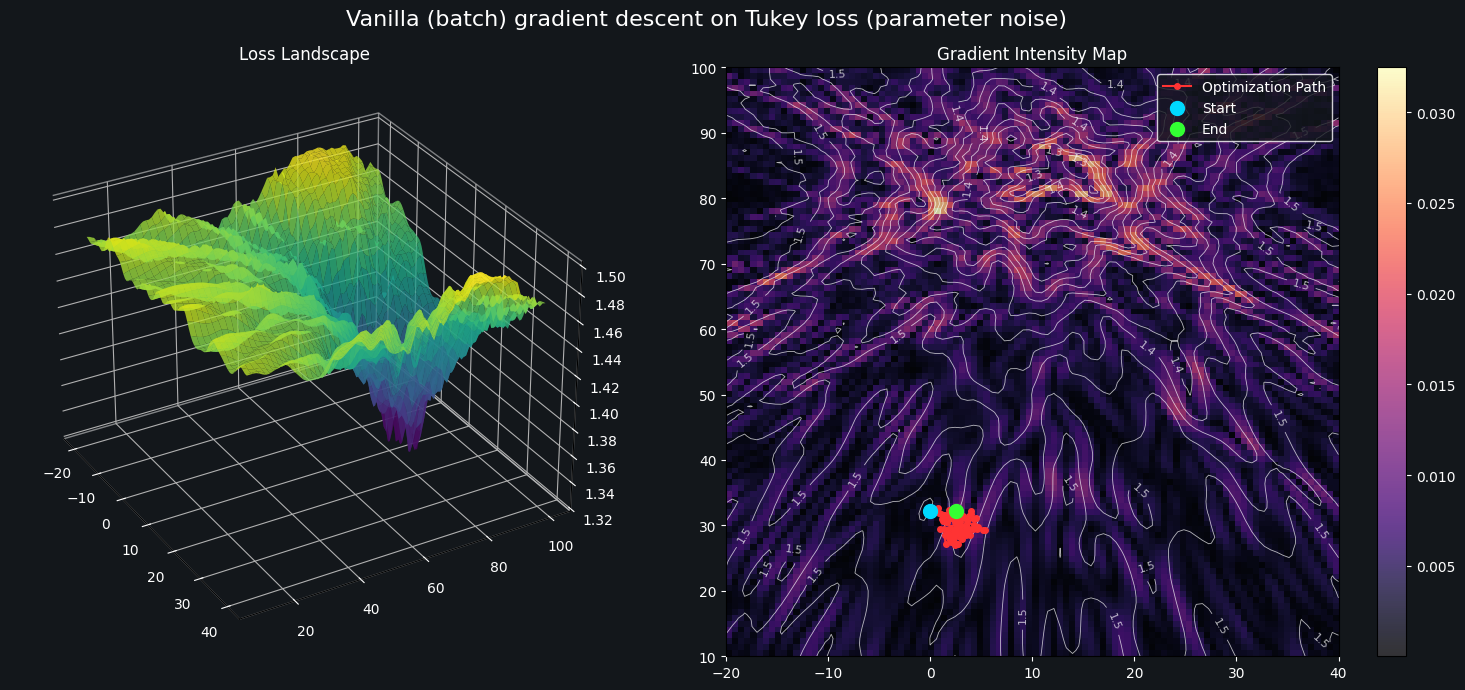

In [ ]:
current_w = initial_coeffs.copy().astype(float)
path_noise = [current_w.copy()]
lr_std = 1.0
sigma = 0.5

for _ in range(100):
    y_pred = np.hstack([np.ones_like(X), X]) @ current_w
    grad = grad_fn(X, y, y_pred)
    noise = np.random.normal(0, sigma, size=current_w.shape)
    current_w = current_w - lr_std * grad + noise
    path_noise.append(current_w.copy())

plot_optimization_progress(X, y, loss_fn, grad_fn, path=path_noise, title='Vanilla (batch) gradient descent on Tukey loss (parameter noise)')

/tmp/ipykernel_1398/3389250277.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r.-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='Optimization Path', color='#ff3333')


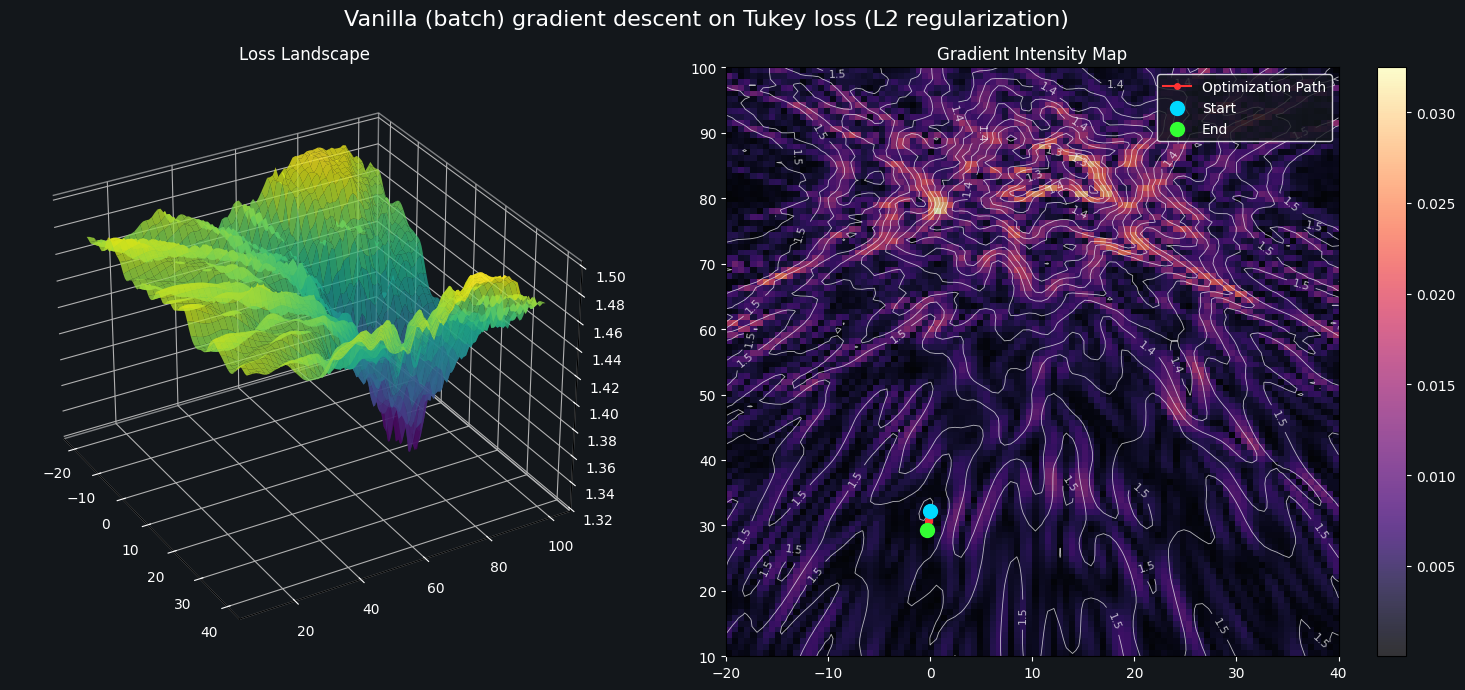

In [ ]:
lambda_reg = 0.001

def reg_loss(y, yp): return loss_fn(y, yp) # Landscape plotting usually ignores the weight penalty for visualization
def reg_grad(X, y, yp):
    # Here we simulate the effect of the gradient pulling towards zero
    return grad_fn(X, y, yp) + lambda_reg * current_w

current_w = initial_coeffs.copy().astype(float)
path_reg = [current_w.copy()]
lr_reg = 1.0

for _ in range(100):
    y_pred = np.hstack([np.ones_like(X), X]) @ current_w
    grad = grad_fn(X, y, y_pred) + lambda_reg * current_w
    current_w -= lr_reg * grad
    path_reg.append(current_w.copy())

plot_optimization_progress(X, y, loss_fn, grad_fn, path=path_reg, title='Vanilla (batch) gradient descent on Tukey loss (L2 regularization)')

This is why we need to fundamentally change our approach to weight-updates, because vanilla gradient descent algorithm cannot work in these sparse conditions. Or, to put it in another way, we need to change our optimizer.

## Stochastic gradient descent (SGD): uniform sampling of $\{X,Y\}$ subset of training data without replacement at every step
We can also choose a speific size of the subset (batch size $b$). If $b\gt1$ - we refer to this version of SGD as mini-batch gradient descent. Although it's a nice idea that gives us an unbiased estimate (expectation over all mini-batched gradients is equal to the value of the vanilla gradient), in our problem we suffer from a lot of zero signal, which undermines SGD's capabilities.

/tmp/ipykernel_8779/1589910960.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r.-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='Optimization Path', color='#ff3333')


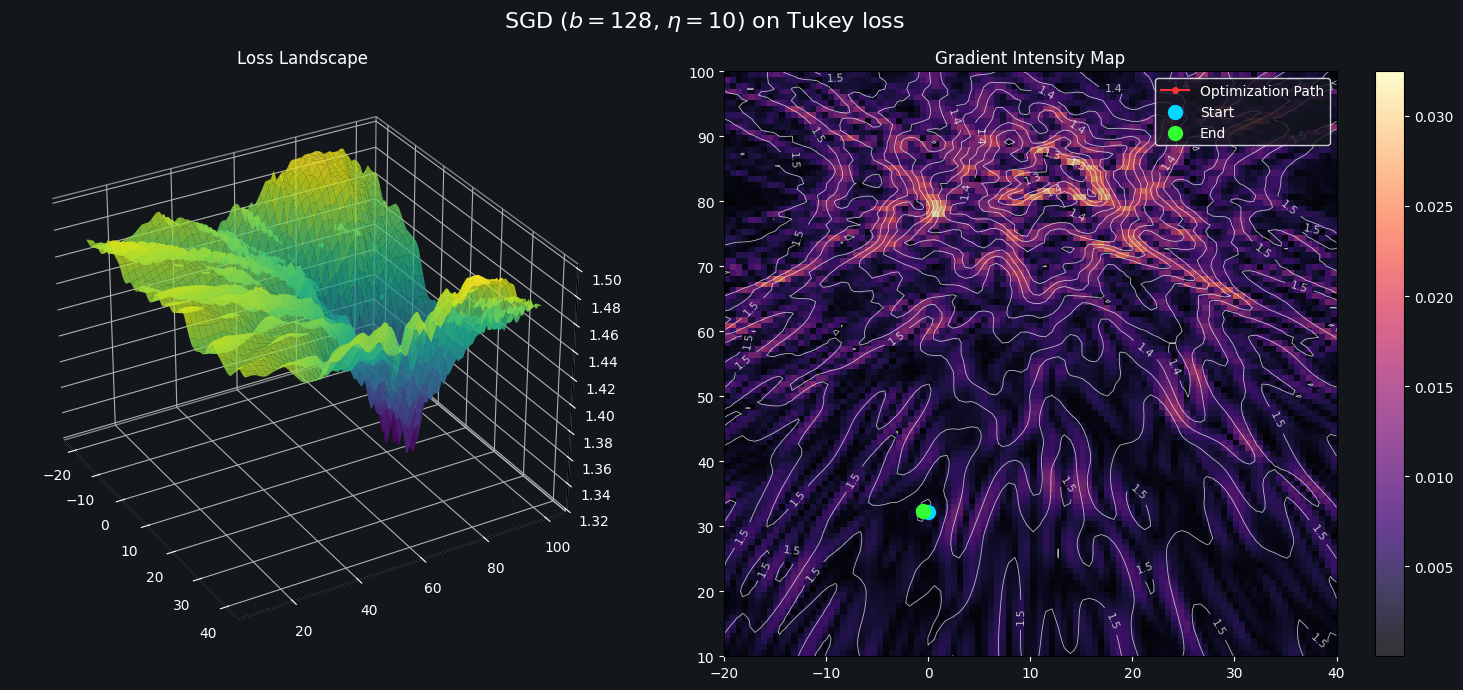

In [ ]:
def sgd(loss_fn, grad_fn,
        X, y, initial_coeffs, lr,
        batch_size, n_epochs) -> list:
  current_w = initial_coeffs.copy().astype(float)
  path = [current_w.copy()]
  for _ in range(n_epochs):
    shuffled_indices = np.random.permutation(len(X))
    for i in range(0, len(X), batch_size):
      batch_indices = shuffled_indices[i:min(i+batch_size,len(X))]
      batch_x, batch_y = X[batch_indices,:], y[batch_indices]
      y_pred = np.hstack([np.ones_like(batch_x), batch_x]) @ current_w
      grad = grad_fn(batch_x, batch_y, y_pred)
      current_w -= lr * grad
      path.append(current_w.copy())
  return path

lr = 10
N_EPOCHS = 200
BATCH_SIZE = 128

path = sgd(loss_fn, grad_fn,
           X, y, initial_coeffs, lr,
           BATCH_SIZE, N_EPOCHS)

plot_optimization_progress(
  X, y,
  loss_fn=loss_fn, grad_fn=grad_fn,
  path=path, rotate_loss_by_deg=30,
  title=fr'SGD ($b={BATCH_SIZE}$, $\eta={lr}$) on Tukey loss'
)

## SGD w/ momentum: natural acelleration of the gradient:
$$
v_t = \gamma v_{t-1} + \eta \nabla_{\theta} L(\theta) \\
\theta = \theta - v_t
$$, where $\eta$ is learning rate.



/tmp/ipykernel_8779/1589910960.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r.-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='Optimization Path', color='#ff3333')


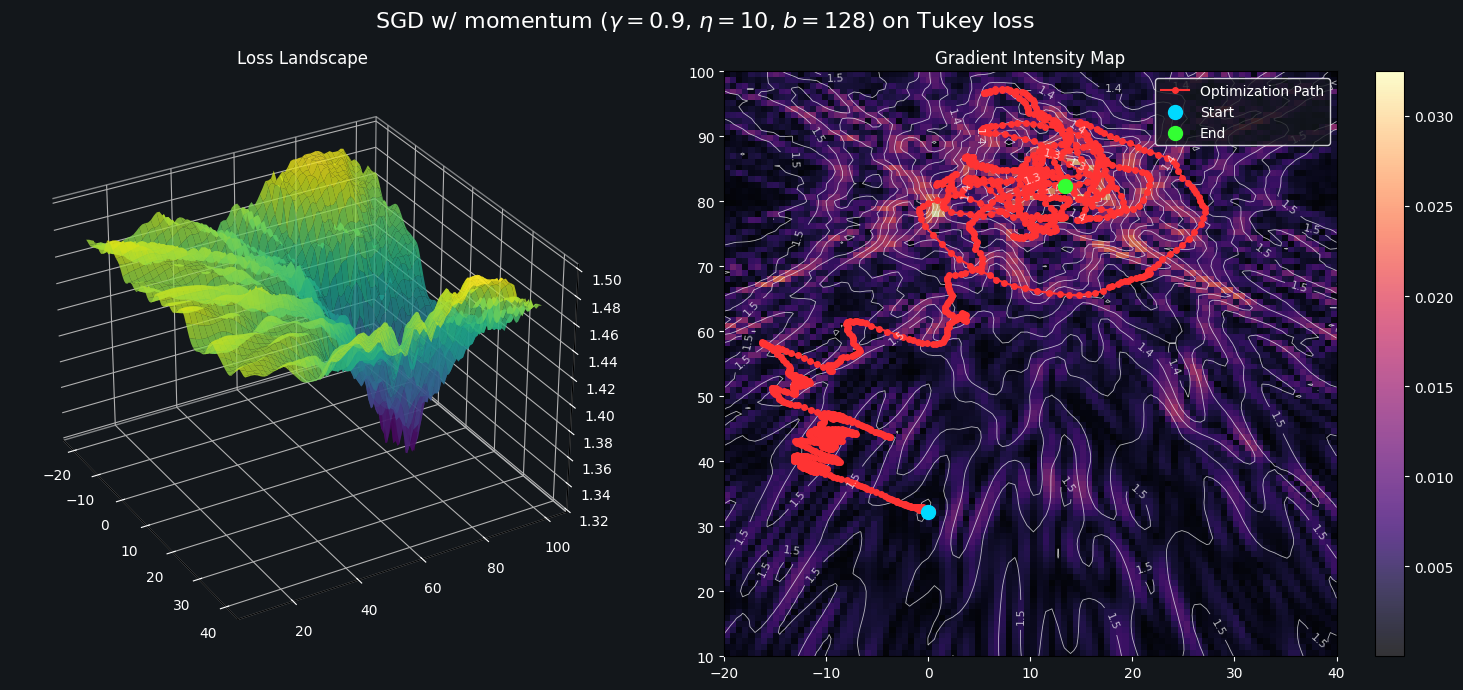

In [ ]:
def sgd_w_momentum(
    loss_fn, grad_fn,
    X, y, initial_coeffs, lr,
    batch_size, n_epochs, gamma = 0.1
  ) -> list:
  current_w = initial_coeffs.copy().astype(float)
  path = [current_w.copy()]
  velocity = np.zeros_like(current_w)
  for _ in range(n_epochs):
    shuffled_indices = np.random.permutation(len(X))
    for i in range(0, len(X), batch_size):
      batch_indices = shuffled_indices[i:min(i+batch_size,len(X))]
      batch_x, batch_y = X[batch_indices,:], y[batch_indices]
      y_pred = np.hstack([np.ones_like(batch_x), batch_x]) @ current_w
      grad = grad_fn(batch_x, batch_y, y_pred)
      velocity = gamma * velocity + lr * grad
      current_w -= velocity
      path.append(current_w.copy())
  return path

lr = 10
N_EPOCHS = 200
BATCH_SIZE = 128
GAMMA = 0.9

path = sgd_w_momentum(loss_fn, grad_fn,
           X, y, initial_coeffs, lr,
           BATCH_SIZE, N_EPOCHS, gamma=GAMMA)

plot_optimization_progress(
  X, y,
  loss_fn=loss_fn, grad_fn=grad_fn,
  path=path, rotate_loss_by_deg=30,
  title=fr'SGD w/ momentum ($\gamma={GAMMA}$, $\eta={lr}$, $b={BATCH_SIZE}$) on Tukey loss'
)

## Nesterov accelerated gradient (improved SGD w/ momentum):
$$
\begin{aligned}
& \theta_{\text{lookahead}} = \theta - \gamma v_{t-1} \\
v_t & =\gamma v_{t-1}+\eta \nabla_{\theta_{\text{lookahead}}} J(\theta_{\text{lookahead}}) \\
\theta & =\theta-v_t
\end{aligned}
$$

Allows us not to overshot by taking the gradient with respect to parameters that have been moved (i.e. we do a simple look-ahead)

/tmp/ipykernel_13699/1589910960.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r.-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='Optimization Path', color='#ff3333')


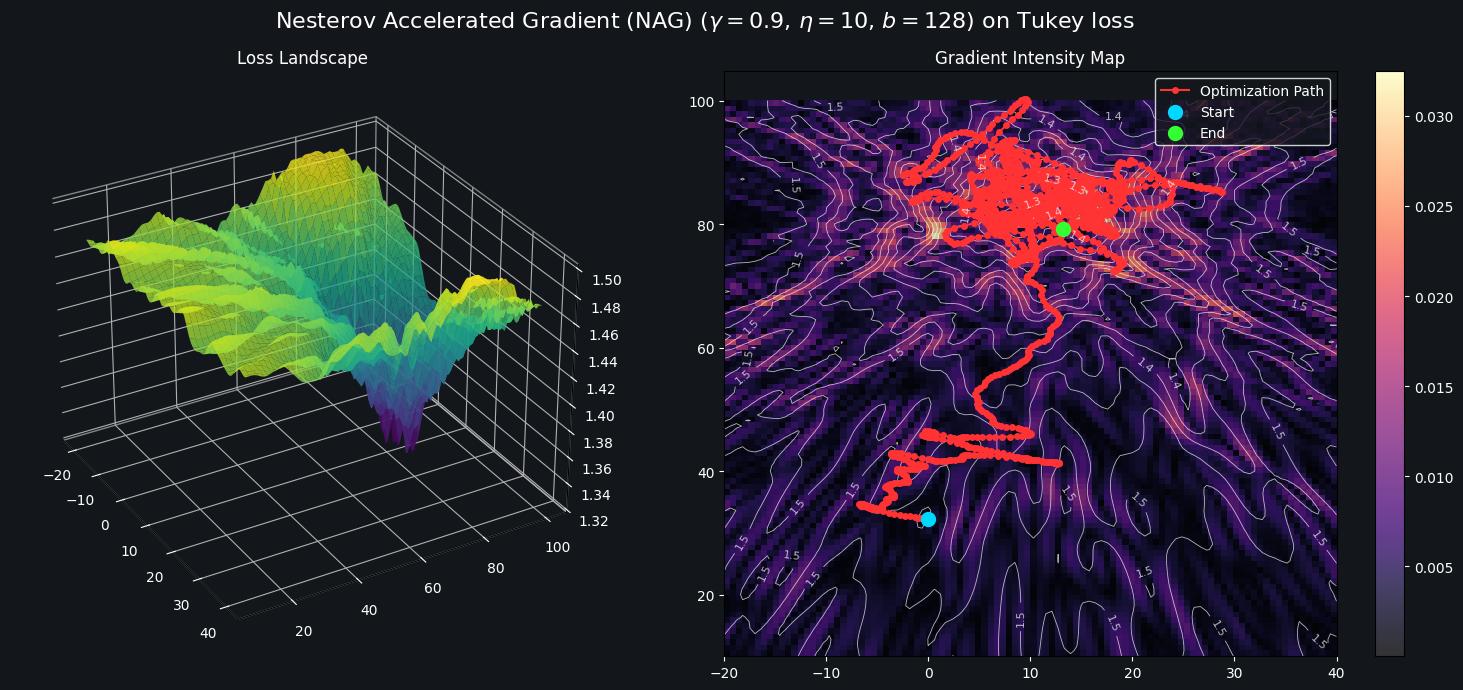

In [5]:
def nag(
    loss_fn, grad_fn,
    X, y, initial_coeffs, lr,
    batch_size, n_epochs, gamma = 0.1
  ) -> list:
  current_w = initial_coeffs.copy().astype(float)
  path = [current_w.copy()]
  velocity = np.zeros_like(current_w)
  lookahead_w = current_w.copy()
  for _ in range(n_epochs):
    shuffled_indices = np.random.permutation(len(X))
    for i in range(0, len(X), batch_size):
      lookahead_w = current_w - gamma * velocity
      batch_indices = shuffled_indices[i:min(i+batch_size,len(X))]
      batch_x, batch_y = X[batch_indices,:], y[batch_indices]
      y_pred = np.hstack([np.ones_like(batch_x), batch_x]) @ lookahead_w
      grad = grad_fn(batch_x, batch_y, y_pred)
      velocity = gamma * velocity + lr * grad
      current_w -= velocity
      path.append(current_w.copy())
  return path

lr = 10
N_EPOCHS = 200
BATCH_SIZE = 128
GAMMA = 0.9

path = nag(loss_fn, grad_fn,
           X, y, initial_coeffs, lr,
           BATCH_SIZE, N_EPOCHS, gamma=GAMMA)

plot_optimization_progress(
  X, y,
  loss_fn=loss_fn, grad_fn=grad_fn,
  path=path, rotate_loss_by_deg=30,
  title=fr'Nesterov Accelerated Gradient (NAG) ($\gamma={GAMMA}$, $\eta={lr}$, $b={BATCH_SIZE}$) on Tukey loss'
)

## Adagrad:
$$
\theta_{t+1}=\theta_t-\frac{\eta}{\sqrt{G_t+\epsilon}} \odot g_t
$$, where $g_t$ - gradient at timestep $t$ (1-st, 2-nd, ... batch), $G_t$ - vector (w.r.t. to every $\theta_i$) of sums of squared past gradients, $ϵ$ - is a small contant for handling divisions by zero and $\odot$ - element-wise multiplication.


Adagrad is an extension of SGD. It "adapts" learning rate to every parameter based on the past history of gradients. Unlike momentum, here we're infinitely shrinking learning rate (because $G_t→\infty$), but at a different pace for every parameter.

/tmp/ipykernel_4826/1589910960.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r.-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='Optimization Path', color='#ff3333')


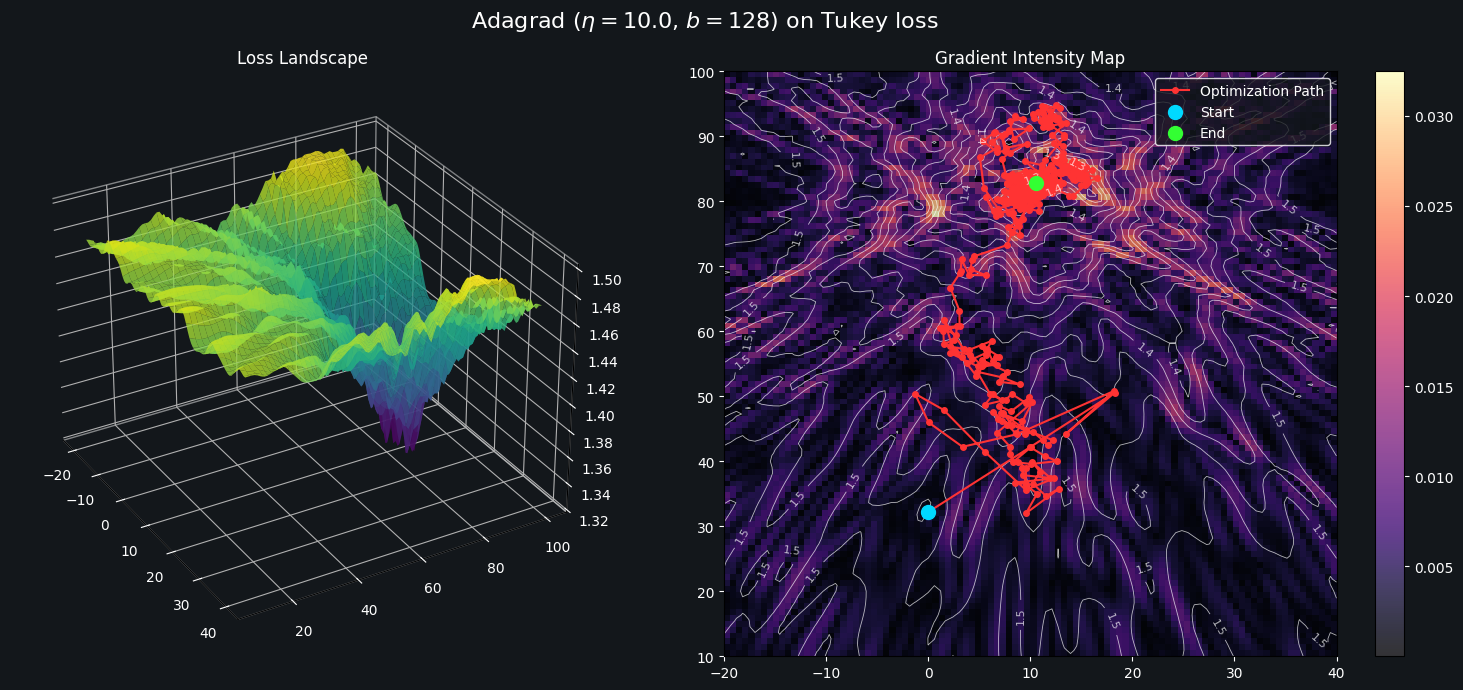

In [ ]:
def adagard(
    loss_fn, grad_fn,
    X, y, initial_coeffs, lr,
    batch_size, n_epochs
  ) -> list:
  current_w = initial_coeffs.copy().astype(float)
  path = [current_w.copy()]
  sum_of_squared_grads = np.zeros_like(current_w)
  for _ in range(n_epochs):
    shuffled_indices = np.random.permutation(len(X))
    for i in range(0, len(X), batch_size):
      batch_indices = shuffled_indices[i:min(i+batch_size,len(X))]
      batch_x, batch_y = X[batch_indices,:], y[batch_indices]
      y_pred = np.hstack([np.ones_like(batch_x), batch_x]) @ current_w
      grad = grad_fn(batch_x, batch_y, y_pred)

      sum_of_squared_grads += grad ** 2
      adapt_lr = lr / (np.sqrt(sum_of_squared_grads) + 1e-8)

      current_w -= adapt_lr * grad
      path.append(current_w.copy())
  return path

lr = 10.0
N_EPOCHS = 200
BATCH_SIZE = 128

path = adagard(loss_fn, grad_fn,
               X, y, initial_coeffs, lr,
               BATCH_SIZE, N_EPOCHS)

plot_optimization_progress(
  X, y,
  loss_fn=loss_fn, grad_fn=grad_fn,
  path=path, rotate_loss_by_deg=30,
  title=fr'Adagrad ($\eta={lr}$, $b={BATCH_SIZE}$) on Tukey loss'
)

## Adadelta:
$$
\begin{aligned}
\Delta \theta_t & =-\frac{R M S[\Delta \theta]_{t-1}}{R M S[g]_t} g_t \\
\theta_{t+1} & =\theta_t+\Delta \theta_t
\end{aligned}
$$, where:
* $R M S[x]_t=\sqrt{E\left[x^2\right]_t+\epsilon}$
* $E\left[x\right]_t=\gamma E\left[x\right]_{t-1}+(1-\gamma) x$ (also refered to as Exponential Moving Average (e.g. in finance $EMA_t = (1 - \alpha) EMA_{t-1} + \alpha P_t$), that smoothes out "historical" changes in gradient magnitude)

Improved adagard, where we completely disregard the learning rate. Instead we scale our parameter updates described by a separate EMA by how much of the expected gradient (EMA) explained by the gradient itself (i.e., if $g_t\lt RMS[g]_t$ then the delta decreases, otherwise we might be oversmoothing and we need to adjust delta by amplifying it, essentially contributing to an overall increase in $\theta$).

By switching $\eta$ to $R M S[\Delta \theta]_{t-1}$ we fix the problem with:
* self annealing
* parameter dependence

/tmp/ipykernel_13699/1589910960.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r.-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='Optimization Path', color='#ff3333')


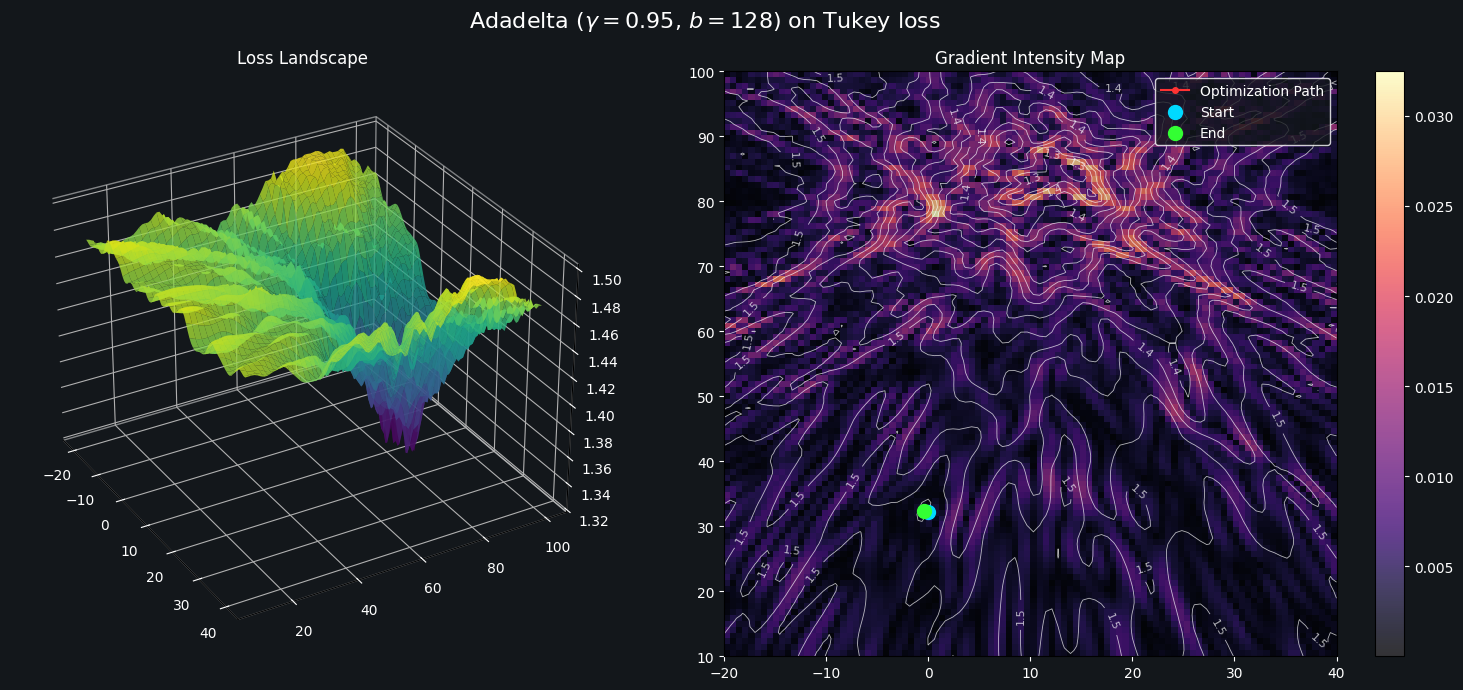

In [6]:
def adadelta(
    loss_fn, grad_fn,
    X, y, initial_coeffs,
    batch_size, n_epochs, gamma=0.95
  ) -> list:
  current_w = initial_coeffs.copy().astype(float)
  path = [current_w.copy()]

  E_g2 = np.zeros_like(current_w)
  E_delta2 = np.zeros_like(current_w)
  eps = 1e-6

  for _ in range(n_epochs):
    shuffled_indices = np.random.permutation(len(X))
    for i in range(0, len(X), batch_size):
      batch_indices = shuffled_indices[i:min(i+batch_size,len(X))]
      batch_x, batch_y = X[batch_indices,:], y[batch_indices]
      y_pred = np.hstack([np.ones_like(batch_x), batch_x]) @ current_w
      grad = grad_fn(batch_x, batch_y, y_pred)

      E_g2 = gamma * E_g2 + (1 - gamma) * (grad ** 2)

      rms_g = np.sqrt(E_g2 + eps)
      rms_delta = np.sqrt(E_delta2 + eps)
      delta_w = -(rms_delta / rms_g) * grad

      E_delta2 = gamma * E_delta2 + (1 - gamma) * (delta_w ** 2)

      current_w += delta_w
      path.append(current_w.copy())
  return path

N_EPOCHS = 200
BATCH_SIZE = 128
GAMMA_ADADELTA = 0.95

path = adadelta(loss_fn, grad_fn,
                X, y, initial_coeffs,
                BATCH_SIZE, N_EPOCHS, gamma=GAMMA_ADADELTA)

plot_optimization_progress(
  X, y,
  loss_fn=loss_fn, grad_fn=grad_fn,
  path=path, rotate_loss_by_deg=30,
  title=fr'Adadelta ($\gamma={GAMMA_ADADELTA}$, $b={BATCH_SIZE}$) on Tukey loss'
)

## RMSPRop:
$$
\begin{aligned}
E\left[g^2\right]_t & =0.9 E\left[g^2\right]_{t-1}+0.1 g_t^2 \\
\theta_{t+1} & =\theta_t-\frac{\eta}{\sqrt{E\left[g^2\right]_t+\epsilon}} g_t
\end{aligned}
$$

Because we don't have much control over intensity of rate of change in Adadelta (hence the bad convergence rate), we can use RMSProp instead. We do need to choose our learning rate more carefully now though, because unlike Adagard the denominator no longer monotonically decreases.

/tmp/ipykernel_4826/1589910960.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r.-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='Optimization Path', color='#ff3333')


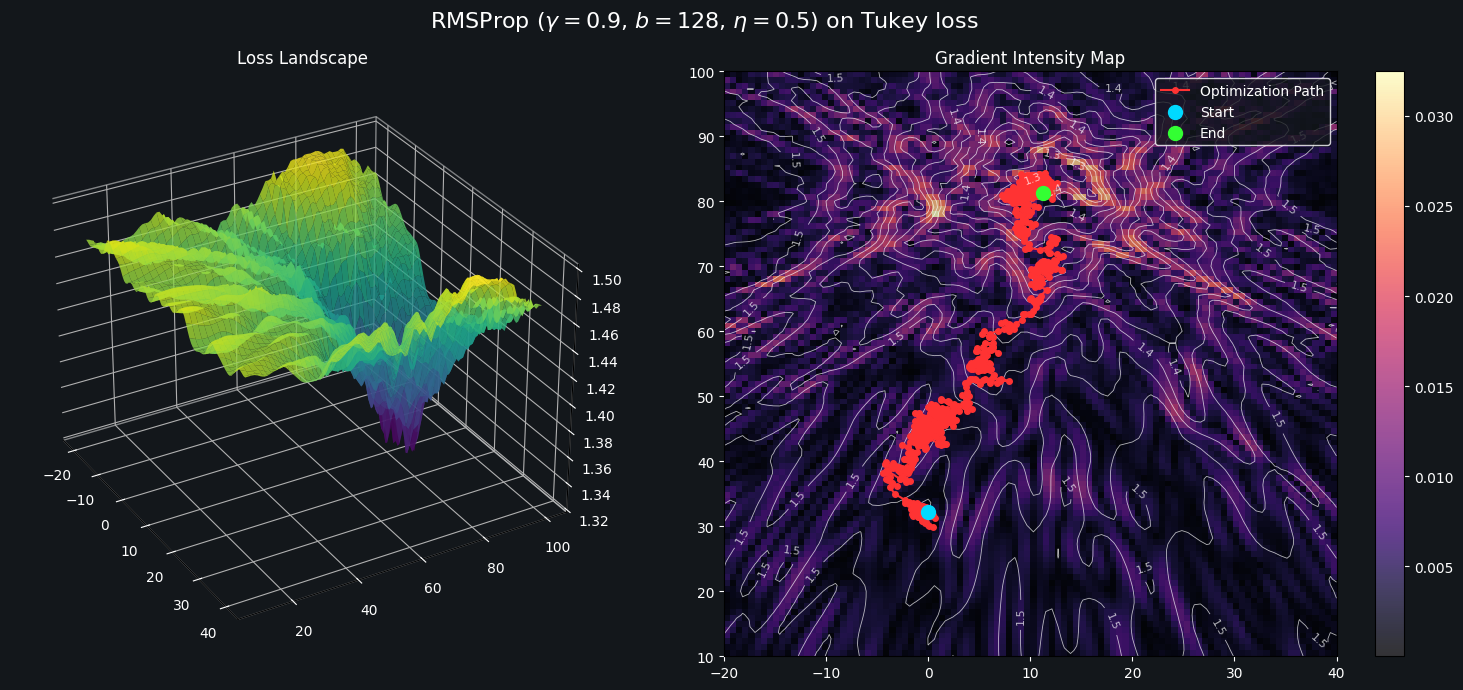

In [ ]:
def rmsprop(
    loss_fn, grad_fn,
    X, y, initial_coeffs,
    batch_size, n_epochs, gamma=0.95, lr=0.1
  ) -> list:
  current_w = initial_coeffs.copy().astype(float)
  path = [current_w.copy()]

  E_g2 = np.zeros_like(current_w)
  eps = 1e-6

  for _ in range(n_epochs):
    shuffled_indices = np.random.permutation(len(X))
    for i in range(0, len(X), batch_size):
      batch_indices = shuffled_indices[i:min(i+batch_size,len(X))]
      batch_x, batch_y = X[batch_indices,:], y[batch_indices]
      y_pred = np.hstack([np.ones_like(batch_x), batch_x]) @ current_w
      grad = grad_fn(batch_x, batch_y, y_pred)

      E_g2 = gamma * E_g2 + (1 - gamma) * (grad ** 2)

      rms_g = np.sqrt(E_g2 + eps)
      delta_w = -(lr / rms_g) * grad

      current_w += delta_w
      path.append(current_w.copy())
  return path

N_EPOCHS = 200
BATCH_SIZE = 128
GAMMA = 0.9
LR = 0.5

path = rmsprop(loss_fn, grad_fn,
                X, y, initial_coeffs,
                BATCH_SIZE, N_EPOCHS, gamma=GAMMA, lr=LR)

plot_optimization_progress(
  X, y,
  loss_fn=loss_fn, grad_fn=grad_fn,
  path=path, rotate_loss_by_deg=30,
  title=fr'RMSProp ($\gamma={GAMMA}$, $b={BATCH_SIZE}$, $\eta={LR}$) on Tukey loss'
)

## Adaptive Moment Estimation (Adam):
$$
\begin{aligned}
m_t & =\beta_1 m_{t-1}+\left(1-\beta_1\right) g_t \\
v_t & =\beta_2 v_{t-1}+\left(1-\beta_2\right) g_t^2 \\
\hat{m}_t & =\frac{m_t}{1-\beta_1^t} \\
\hat{v}_t & =\frac{v_t}{1-\beta_2^t} \\
\theta_{t+1} & =\theta_t-\frac{\eta}{\sqrt{\hat{v}_t}+\epsilon} \hat{m}_t
\end{aligned}
$$
Adam is a mix of RMSProp and SGD w/ momentum. $m_t$ and $v_t$ are also refered to as statistical raw (uncentered) moments (1st and 2nd accordingly). $\hat{m}_t$ and $\hat{v}_t$ are used to artificially boost rate of change in early timesteps of $t$.

/tmp/ipykernel_13699/1589910960.py:60: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r.-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(path[:, 0], path[:, 1], 'r.-', markersize=8, label='Optimization Path', color='#ff3333')


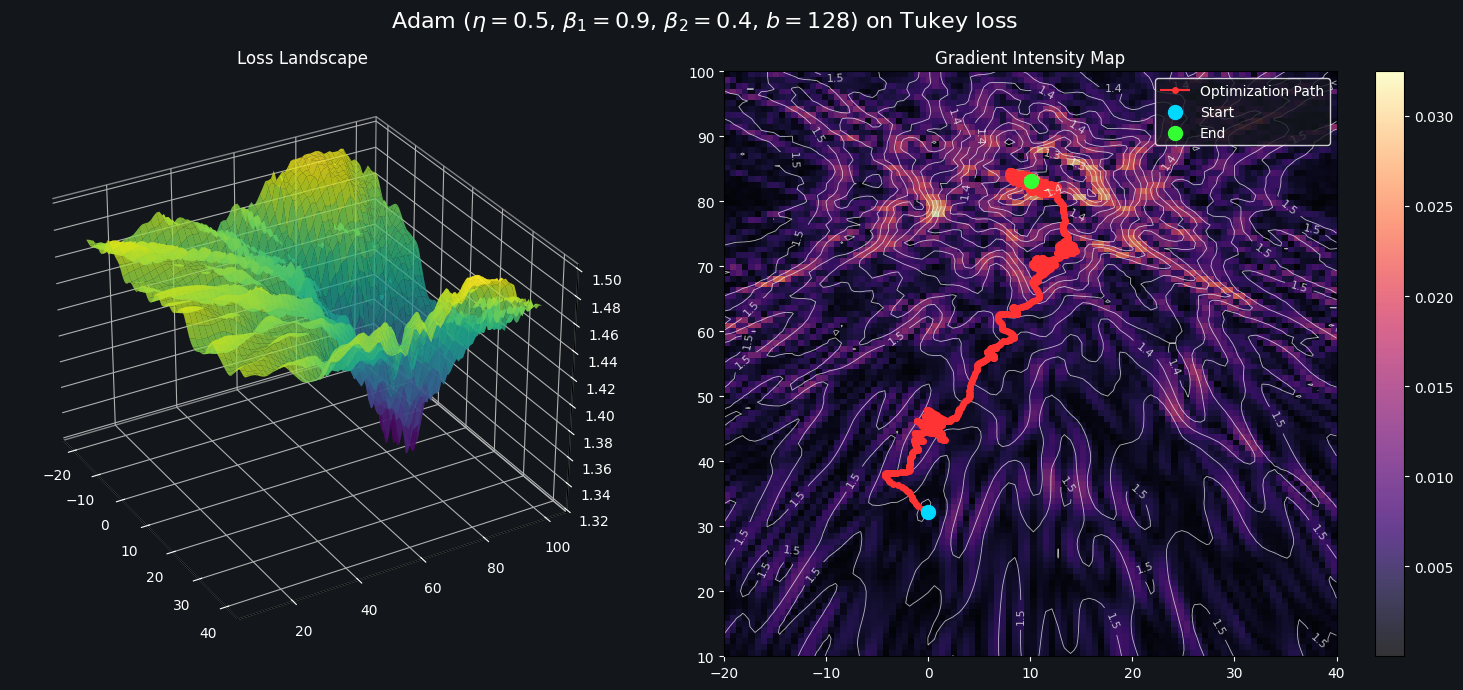

In [15]:
def adam(
    loss_fn, grad_fn,
    X, y, initial_coeffs,
    batch_size, n_epochs,
    lr=0.5, beta1=0.9, beta2=0.999
  ) -> list:
  current_w = initial_coeffs.copy().astype(float)
  path = [current_w.copy()]

  m = np.zeros_like(current_w)
  v = np.zeros_like(current_w)
  eps = 1e-8
  t = 0

  for _ in range(n_epochs):
    shuffled_indices = np.random.permutation(len(X))
    for i in range(0, len(X), batch_size):
      t += 1
      batch_indices = shuffled_indices[i:min(i+batch_size,len(X))]
      batch_x, batch_y = X[batch_indices,:], y[batch_indices]
      y_pred = np.hstack([np.ones_like(batch_x), batch_x]) @ current_w
      grad = grad_fn(batch_x, batch_y, y_pred)

      m = beta1 * m + (1 - beta1) * grad
      v = beta2 * v + (1 - beta2) * (grad ** 2)

      m_hat = m / (1 - beta1 ** t)
      v_hat = v / (1 - beta2 ** t)

      current_w -= lr * m_hat / (np.sqrt(v_hat) + eps)
      path.append(current_w.copy())
  return path

N_EPOCHS = 200
BATCH_SIZE = 128
LR = 0.5
BETA1 = 0.9
BETA2 = 0.4

path = adam(loss_fn, grad_fn,
            X, y, initial_coeffs,
            BATCH_SIZE, N_EPOCHS, lr=LR, beta1=BETA1, beta2=BETA2)

plot_optimization_progress(
  X, y,
  loss_fn=loss_fn, grad_fn=grad_fn,
  path=path, rotate_loss_by_deg=30,
  title=fr'Adam ($\eta={LR}$, $\beta_1={BETA1}$, $\beta_2={BETA2}$, $b={BATCH_SIZE}$) on Tukey loss'
)